# 🇱🇰 Sri Lankan IT/Tech Job Market Analysis
### Data collected via web scraping from ikman.lk
**Dataset:** 216 job listings across 5 IT/tech categories  



## 1. Setup & Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Plot style
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 5),
                     "axes.titlesize": 14, "axes.labelsize": 12})

df = pd.read_csv("data/ikman_jobs_clean.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (216, 10)


,category,title,company,location,salary_min,salary_max,salary_mid,days_ago,detail_url,description
0,IT and Network Industry,Quality Assurance (QA) Engineer,Lakmini International (Pvt) Ltd,Colombo,NaN,NaN,NaN,NaN,https://ikman.lk/en/ad/quality-assurance-qa-en...,Quality Assurance (QA) Engineer Software Testi...
1,IT and Network Industry,Hardware Support Engineer,INFOTECH COMPUTERS PRIVATE LIMITED,Colombo,30000.0,50000.0,40000.0,0.62,https://ikman.lk/en/ad/hardware-support-engine...,A growing IT company based in Colombo is looki...
2,IT and Network Industry,Computer Technician,Miracala Computers,Colombo,NaN,NaN,NaN,0.71,https://ikman.lk/en/ad/computer-technician-col...,WANTED Computer Technician\nJob Duties Compute...
3,IT and Network Industry,Quality Assurance (QA) Engineer,Lakmini International (Pvt) Ltd,Colombo,NaN,NaN,NaN,0.75,https://ikman.lk/en/ad/quality-assurance-qa-en...,Quality Assurance (QA) Engineer Software Testi...
4,IT and Network Industry,JUNIOR TRAINEE (SOFTWARE DEVELOPMENT & IoT) - ...,HEDANS ELECTRICAL,Gampaha,NaN,NaN,NaN,2.00,https://ikman.lk/en/ad/junior-trainee-software...,HEDANS ELECTRICAL\nIt s all about QUALITY Qual...


In [3]:
# Quick overview
print("=== Data Types ===")
print(df.dtypes)
print("\n=== Missing Values ===")
print(df.isna().sum())
print("\n=== Category Distribution ===")
print(df["category"].value_counts())

=== Data Types ===
category        object
title           object
company         object
location        object
salary_min     float64
salary_max     float64
salary_mid     float64
days_ago       float64
detail_url      object
description     object
dtype: object

=== Missing Values ===
category         0
title            0
company          0
location         0
salary_min     155
salary_max     155
salary_mid     155
days_ago         8
detail_url       0
description      0
dtype: int64

=== Category Distribution ===
category
IT and Network Industry    79
Digital Marketing          68
Engineering                45
Analyst                    14
Designer                   10
Name: count, dtype: int64


## 2. Job Distribution by Category

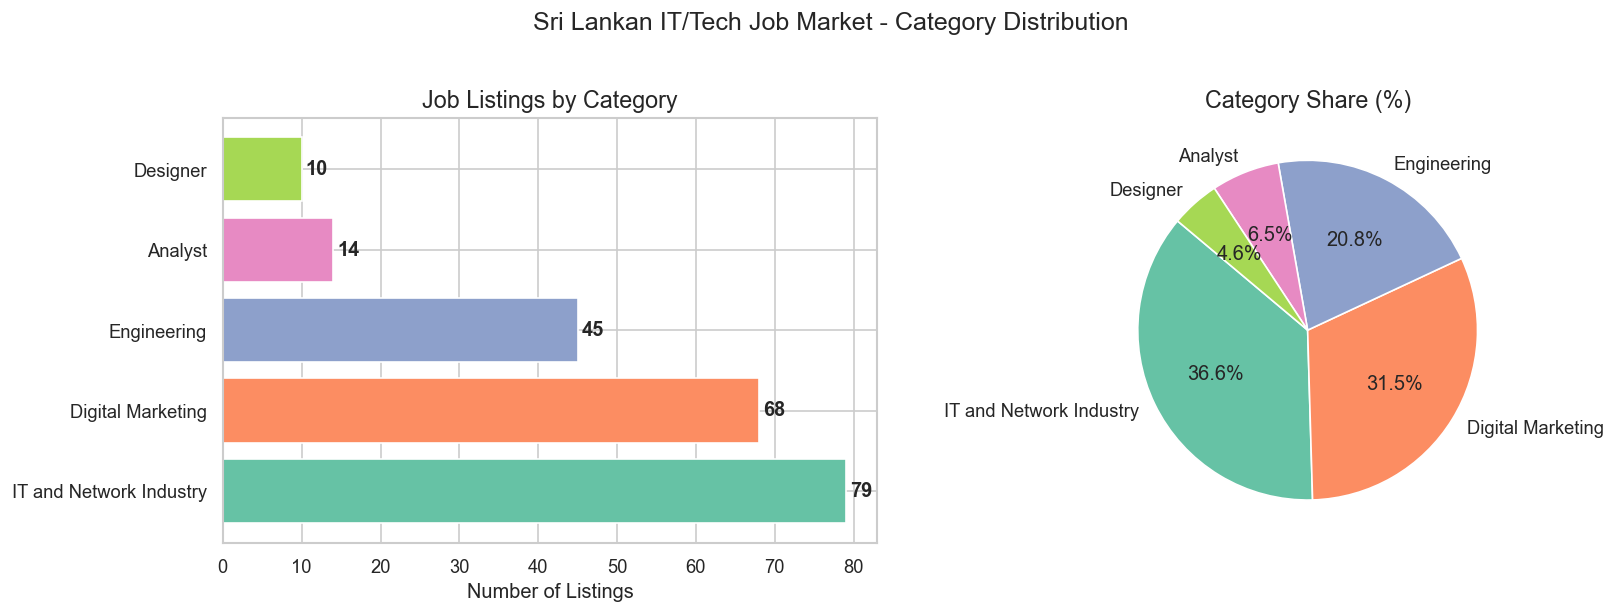

category
IT and Network Industry    79
Digital Marketing          68
Engineering                45
Analyst                    14
Designer                   10


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
cat_counts = df["category"].value_counts()
bars = axes[0].barh(cat_counts.index, cat_counts.values,
                    color=sns.color_palette("Set2", len(cat_counts)))
axes[0].set_xlabel("Number of Listings")
axes[0].set_title("Job Listings by Category")
for bar, val in zip(bars, cat_counts.values):
    axes[0].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 str(val), va="center", fontweight="bold")

# Pie chart
axes[1].pie(cat_counts.values, labels=cat_counts.index,
            autopct="%1.1f%%", startangle=140,
            colors=sns.color_palette("Set2", len(cat_counts)))
axes[1].set_title("Category Share (%)")

plt.suptitle("Sri Lankan IT/Tech Job Market - Category Distribution", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("data/plot_01_category_distribution.png", bbox_inches="tight")
plt.show()
print(cat_counts.to_string())

## 3. Geographic Distribution

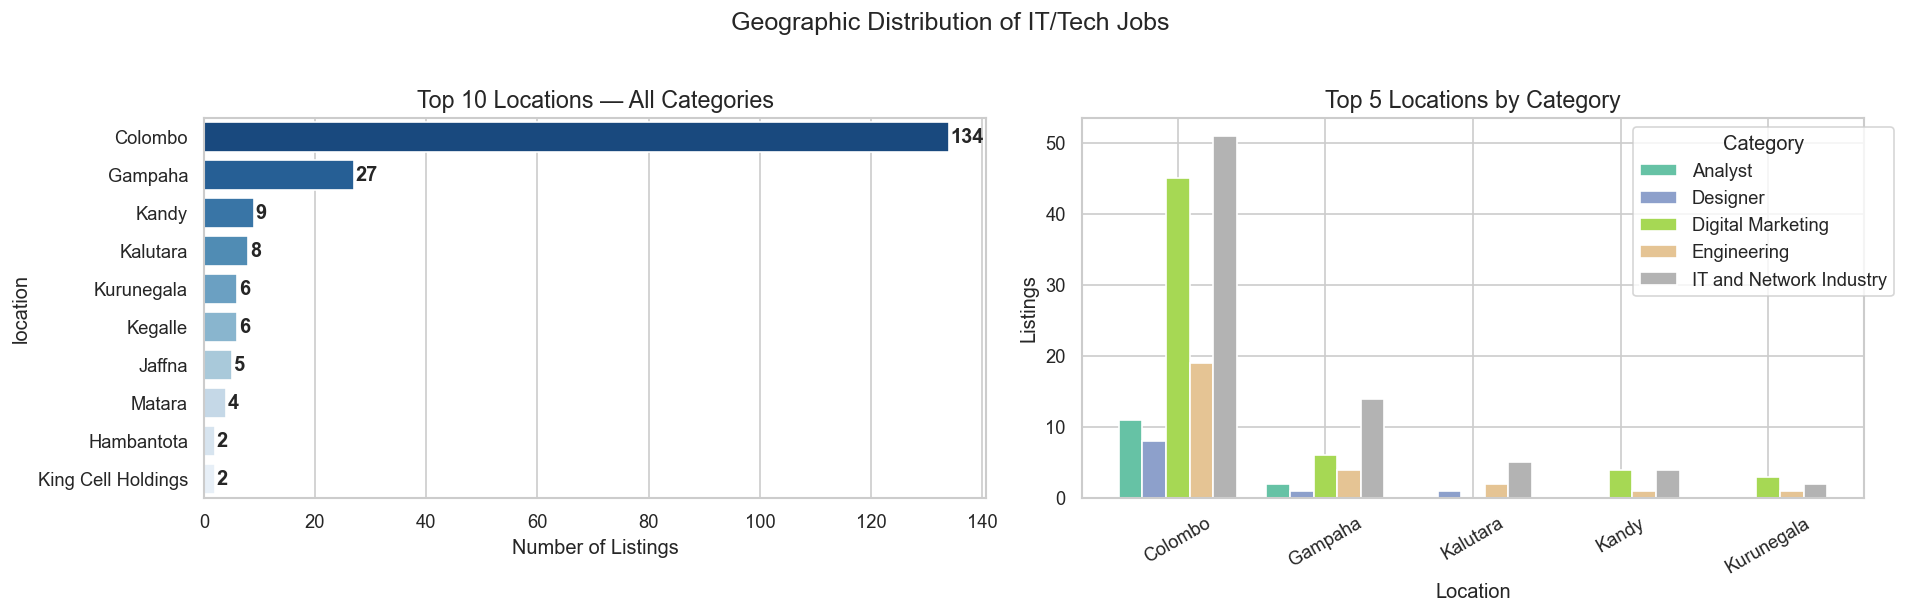

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top 10 locations overall
top_locations = df["location"].value_counts().head(10)
sns.barplot(x=top_locations.values, y=top_locations.index,
            palette="Blues_r", ax=axes[0])
axes[0].set_title("Top 10 Locations — All Categories")
axes[0].set_xlabel("Number of Listings")
for i, v in enumerate(top_locations.values):
    axes[0].text(v + 0.3, i, str(v), va="center", fontweight="bold")

# Location by category (top 5 locations)
top5_locs = df["location"].value_counts().head(5).index
df_top = df[df["location"].isin(top5_locs)]
loc_cat = df_top.groupby(["location", "category"]).size().unstack(fill_value=0)
loc_cat.plot(kind="bar", ax=axes[1], colormap="Set2", width=0.8)
axes[1].set_title("Top 5 Locations by Category")
axes[1].set_xlabel("Location")
axes[1].set_ylabel("Listings")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(title="Category", bbox_to_anchor=(1.05, 1))

plt.suptitle("Geographic Distribution of IT/Tech Jobs", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("data/plot_02_location_distribution.png", bbox_inches="tight")
plt.show()

## 4. Salary Analysis
> Note: Only 90/216 listings disclosed salary (common on classifieds platforms).

In [6]:
df_sal = df.dropna(subset=["salary_mid"]).copy()
print(f"Listings with salary data: {len(df_sal)}")
print(f"\nSalary statistics (LKR):")
print(df_sal[["salary_min", "salary_max", "salary_mid"]].describe().round(0).to_string())

Listings with salary data: 61

Salary statistics (LKR):
       salary_min  salary_max  salary_mid
count        61.0        61.0        61.0
mean      54639.0     89770.0     72205.0
std       29728.0     54919.0     39671.0
min       25000.0     35000.0     32500.0
25%       35000.0     50000.0     45000.0
50%       45000.0     70000.0     62500.0
75%       60000.0    100000.0     90000.0
max      170000.0    300000.0    225000.0


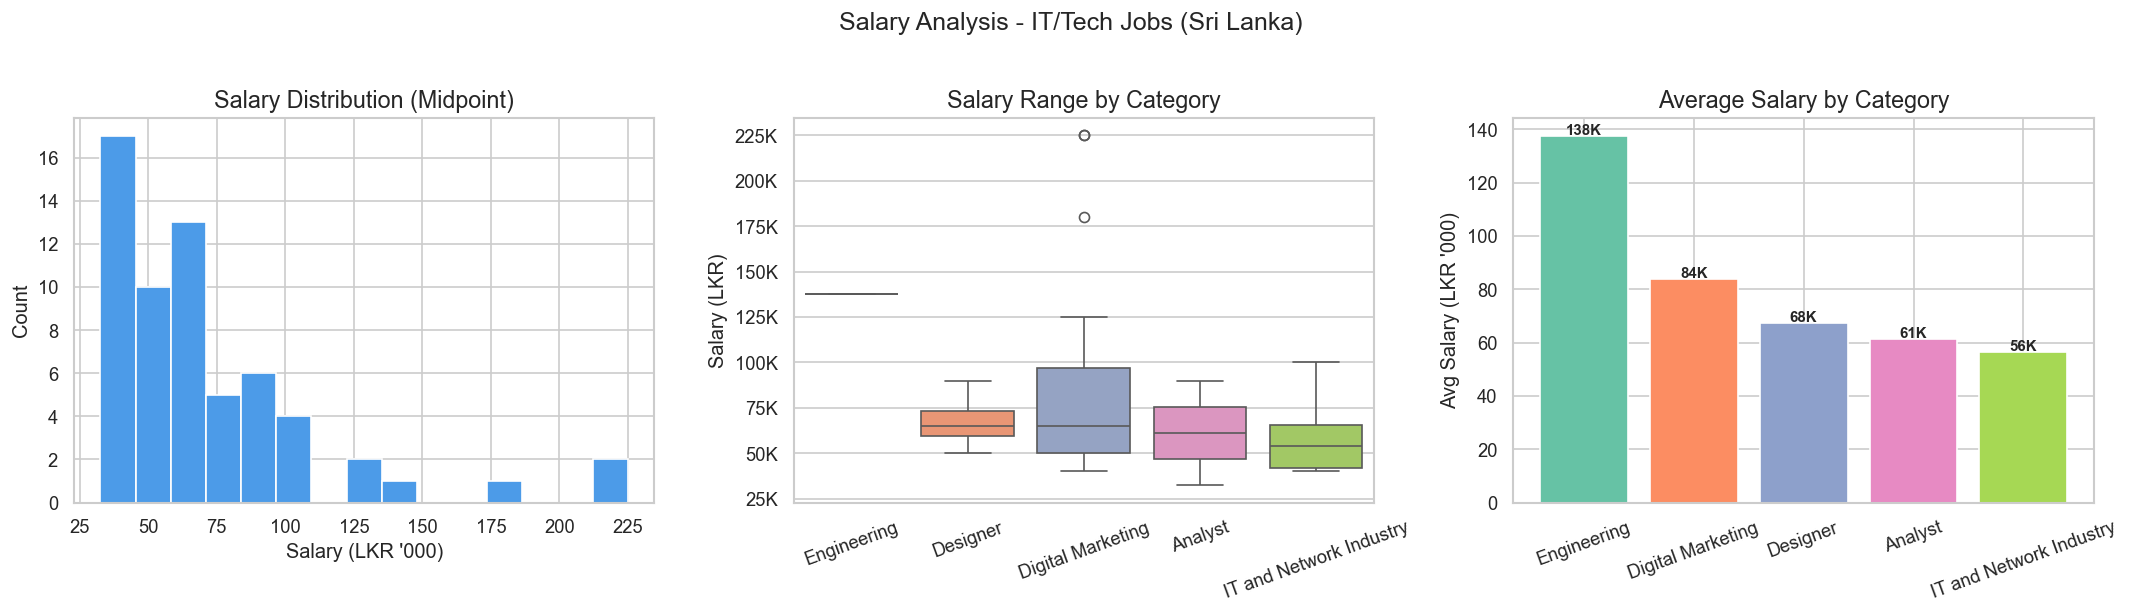

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution of midpoint salary
axes[0].hist(df_sal["salary_mid"] / 1000, bins=15,
             color="#4C9BE8", edgecolor="white")
axes[0].set_title("Salary Distribution (Midpoint)")
axes[0].set_xlabel("Salary (LKR '000)")
axes[0].set_ylabel("Count")

# Salary range by category (box plot)
order = df_sal.groupby("category")["salary_mid"].median().sort_values(ascending=False).index
sns.boxplot(data=df_sal, x="category", y="salary_mid",
            order=order, palette="Set2", ax=axes[1])
axes[1].set_title("Salary Range by Category")
axes[1].set_xlabel("")
axes[1].set_ylabel("Salary (LKR)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
axes[1].tick_params(axis="x", rotation=20)

# Average salary by category (bar)
avg_sal = df_sal.groupby("category")["salary_mid"].mean().sort_values(ascending=False)
bars = axes[2].bar(avg_sal.index, avg_sal.values / 1000,
                   color=sns.color_palette("Set2", len(avg_sal)))
axes[2].set_title("Average Salary by Category")
axes[2].set_xlabel("")
axes[2].set_ylabel("Avg Salary (LKR '000)")
axes[2].tick_params(axis="x", rotation=20)
for bar, val in zip(bars, avg_sal.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{val/1000:.0f}K", ha="center", fontweight="bold", fontsize=9)

plt.suptitle("Salary Analysis - IT/Tech Jobs (Sri Lanka)", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("data/plot_03_salary_analysis.png", bbox_inches="tight")
plt.show()

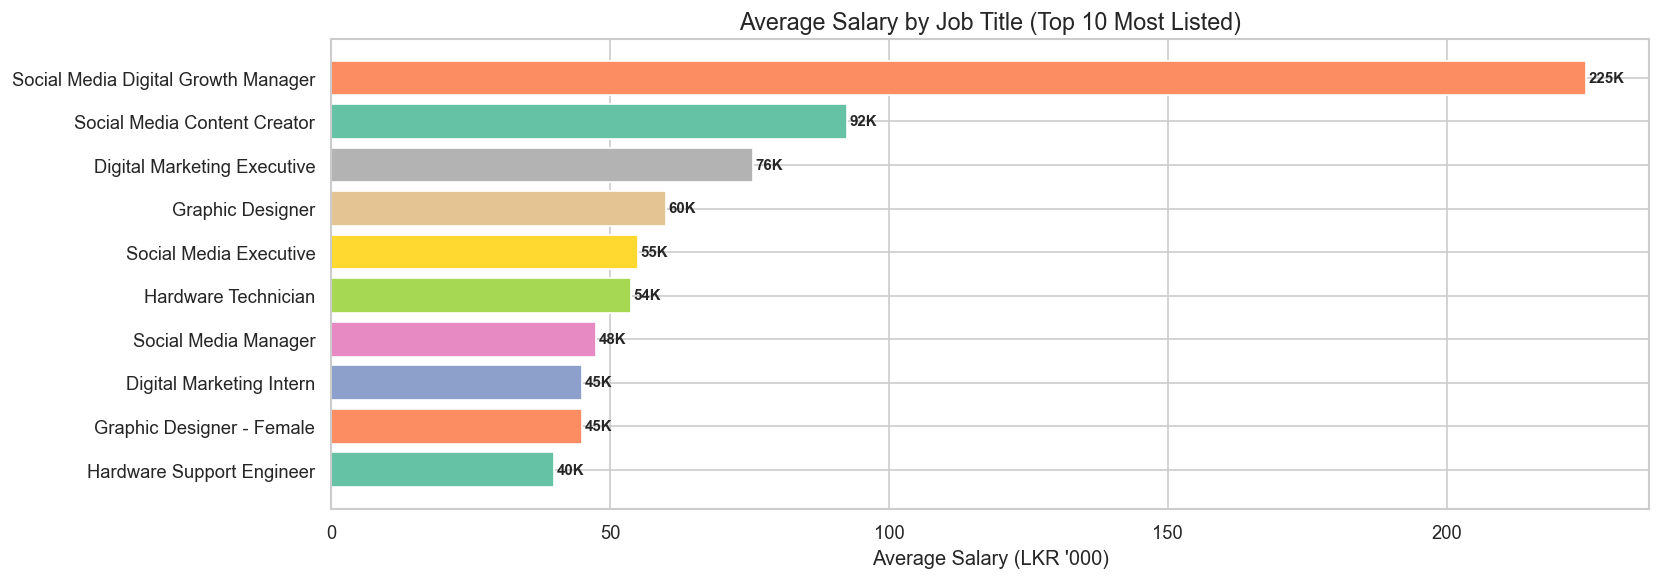

In [12]:
# Average salary by job title (top 10 titles with most salary data)
top_titles = df_sal["title"].value_counts().head(10).index
df_sal_title = df_sal[df_sal["title"].isin(top_titles)]

avg_sal_title = (df_sal_title.groupby("title")["salary_mid"]
                              .mean()
                              .sort_values(ascending=False))

plt.figure(figsize=(14, 5))
bars = plt.barh(avg_sal_title.index[::-1], avg_sal_title.values[::-1] / 1000,
                color=sns.color_palette("Set2", len(avg_sal_title)))
plt.title("Average Salary by Job Title (Top 10 Most Listed)")
plt.xlabel("Average Salary (LKR '000)")
for bar, val in zip(bars, avg_sal_title.values[::-1]):
    plt.text(val / 1000 + 0.5, bar.get_y() + bar.get_height()/2,
             f"{val/1000:.0f}K", va="center", fontweight="bold", fontsize=9)
plt.tight_layout()
plt.savefig("data/plot_04_salary_by_title.png", bbox_inches="tight")
plt.show()

## 5. Job Posting Recency

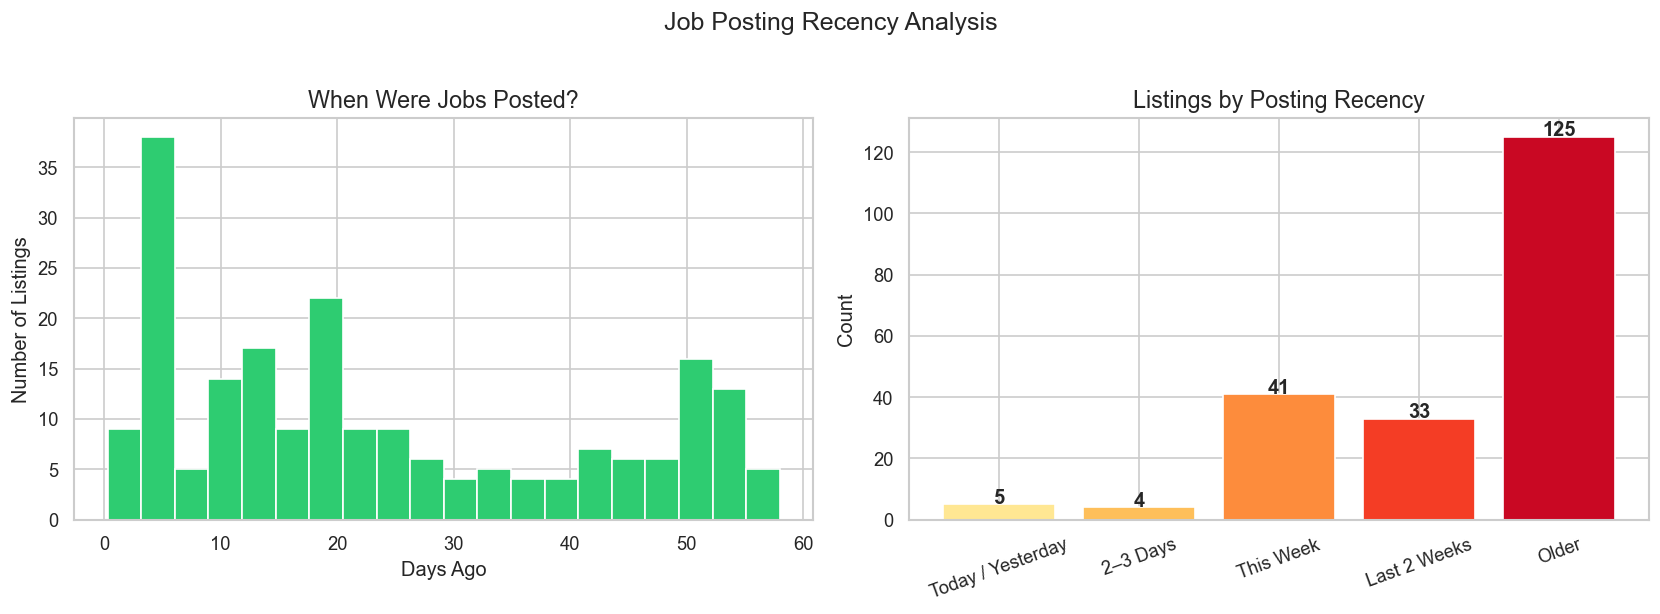

In [9]:
df_days = df.dropna(subset=["days_ago"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of posting recency
axes[0].hist(df_days["days_ago"], bins=20,
             color="#2ECC71", edgecolor="white")
axes[0].set_title("When Were Jobs Posted?")
axes[0].set_xlabel("Days Ago")
axes[0].set_ylabel("Number of Listings")

# Recency buckets
def recency_bucket(d):
    if d <= 1:   return "Today / Yesterday"
    elif d <= 3: return "2–3 Days"
    elif d <= 7: return "This Week"
    elif d <= 14: return "Last 2 Weeks"
    else:        return "Older"

bucket_order = ["Today / Yesterday", "2–3 Days", "This Week", "Last 2 Weeks", "Older"]
df_days["recency"] = df_days["days_ago"].apply(recency_bucket)
recency_counts = df_days["recency"].value_counts().reindex(bucket_order).fillna(0)

axes[1].bar(recency_counts.index, recency_counts.values,
            color=sns.color_palette("YlOrRd", len(recency_counts)))
axes[1].set_title("Listings by Posting Recency")
axes[1].set_xlabel("")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=20)
for i, v in enumerate(recency_counts.values):
    axes[1].text(i, v + 0.3, str(int(v)), ha="center", fontweight="bold")

plt.suptitle("Job Posting Recency Analysis", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("data/plot_05_posting_recency.png", bbox_inches="tight")
plt.show()

## 6. Most Common Job Titles

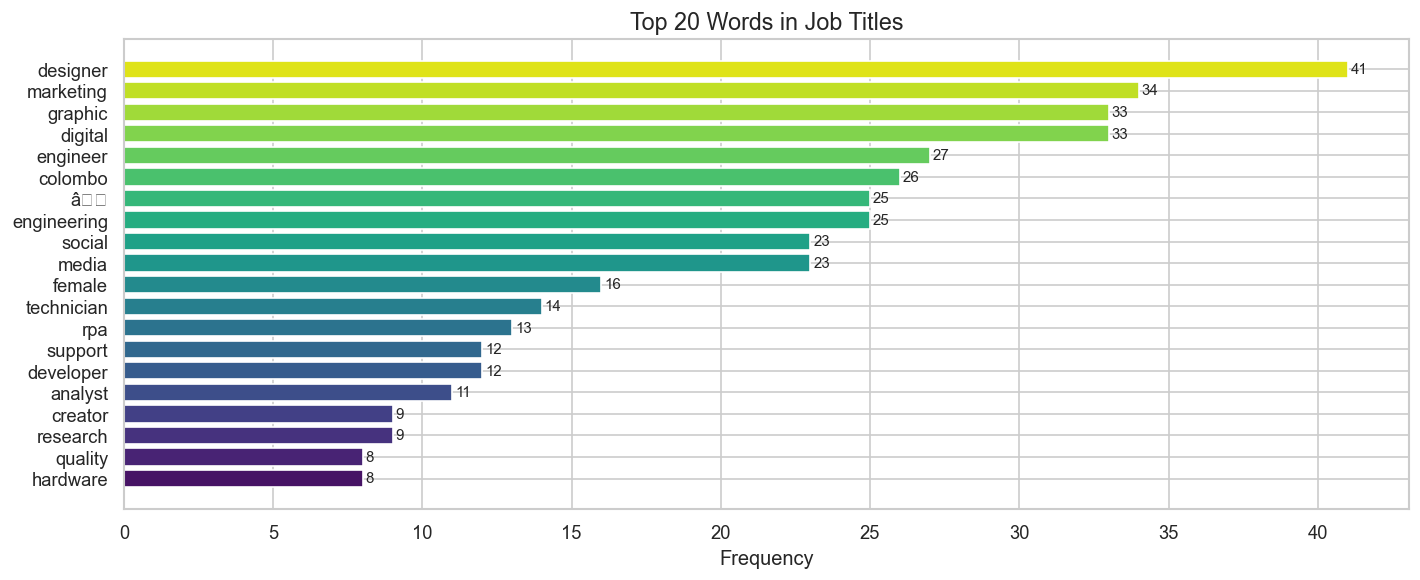

Top 20 title words:
       word  count
   designer     41
  marketing     34
    graphic     33
    digital     33
   engineer     27
    colombo     26
        â     25
engineering     25
     social     23
      media     23
     female     16
 technician     14
        rpa     13
    support     12
  developer     12
    analyst     11
    creator      9
   research      9
    quality      8
   hardware      8


In [10]:
from collections import Counter

# Tokenize job titles
stopwords = {"and", "or", "for", "the", "a", "in", "of", "to", "with",
             "senior", "junior", "assistant", "manager", "executive",
             "officer", "specialist", "intern", "trainee", "pvt", "ltd"}

title_words = []
for title in df["title"].dropna():
    words = [w.lower().strip("()/-") for w in title.split()
             if w.lower().strip("()/-") not in stopwords and len(w) > 2]
    title_words.extend(words)

title_freq = Counter(title_words).most_common(20)
words_df = pd.DataFrame(title_freq, columns=["word", "count"])

plt.figure(figsize=(12, 5))
bars = plt.barh(words_df["word"][::-1], words_df["count"][::-1],
                color=sns.color_palette("viridis", len(words_df)))
plt.title("Top 20 Words in Job Titles")
plt.xlabel("Frequency")
for bar, val in zip(bars, words_df["count"][::-1]):
    plt.text(val + 0.1, bar.get_y() + bar.get_height()/2,
             str(val), va="center", fontsize=9)
plt.tight_layout()
plt.savefig("data/plot_06_title_words.png", bbox_inches="tight")
plt.show()
print("Top 20 title words:")
print(words_df.to_string(index=False))

## 7. Key Insights Summary

In [13]:

print("   IKMAN.LK IT/TECH JOB MARKET — KEY INSIGHTS")


print(f"\n Total listings analysed : {len(df)}")
print(f"  Most active city         : {df['location'].value_counts().index[0]} "
      f"({df['location'].value_counts().iloc[0]} listings)")
print(f"  Largest category         : {df['category'].value_counts().index[0]} "
      f"({df['category'].value_counts().iloc[0]} listings)")

if len(df_sal) > 0:
    print(f"\n Salary insights (n={len(df_sal)}):")
    print(f"   Median salary            : LKR {df_sal['salary_mid'].median():,.0f}")
    print(f"   Highest paying category  : {df_sal.groupby('category')['salary_mid'].mean().idxmax()}")
    print(f"   Lowest paying category   : {df_sal.groupby('category')['salary_mid'].mean().idxmin()}")

print(f"\n Recency:")
fresh = (df_days["days_ago"] <= 7).sum()
print(f"   Posted within last week  : {fresh} listings ({fresh/len(df_days)*100:.1f}%)")


   IKMAN.LK IT/TECH JOB MARKET — KEY INSIGHTS

 Total listings analysed : 216
  Most active city         : Colombo (134 listings)
  Largest category         : IT and Network Industry (79 listings)

 Salary insights (n=61):
   Median salary            : LKR 62,500
   Highest paying category  : Engineering
   Lowest paying category   : IT and Network Industry

 Recency:
   Posted within last week  : 50 listings (24.0%)
